# 05 — SARIMA / SARIMAX

Second of the three model families, and the one that does not fit the same mould as the other
two. That difference has to be handled openly rather than smoothed over, because it decides
what the three-way comparison can legitimately claim.

## The granularity problem

XGBoost and the LSTM predict **the fare of one itinerary at one search date**. SARIMA cannot:
it is a univariate time series model and needs a single ordered series at a fixed interval.
The observations are not that. They are roughly 63,000 short, overlapping per-flight
trajectories whose median length is 20 — far too few points to identify a weekly seasonal
term, and far too many series to fit individually.

The series modelled here is therefore the **daily mean fare per route** — 174 consecutive
days, no gaps. That is a defensible target in its own right: it is the route-level price
signal a revenue manager watches, and it is what "seasonal demand" in the project title
actually refers to. But it is **not the same target** the other two families predict, and RMSE
on daily means is not comparable to RMSE on individual fares. Daily averaging removes most of
the within-day variance, so the numbers would look better for reasons that have nothing to do
with the model.

**The comparison is therefore made on like for like.** Section 6 evaluates persistence and
XGBoost on this same daily series, under the same folds and the same forecasting protocol, so
that the families are ranked on a target all three can actually predict.

## Forecasting protocol

Forecasts are **one step ahead**. Each day in a test window is predicted from actuals up to
the previous day; the model is fitted once on the training window and never refitted inside
the test window. Every family is evaluated identically, so none is given information the
others lack.

## Scope

SARIMA contributes to **research question 1** (fare prediction) and, through SARIMAX's
exogenous calendar terms, to **research question 3**. It contributes nothing to research
question 2: a spike is defined per flight trajectory, so the label does not exist at daily
granularity, and a forecasting model is not a classifier. Spike prediction is left to the tree
and network families, and this is a limitation of the model family rather than an omission.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from flightprice.config import (
    PROCESSED_DIR, PROJECT_ROOT, RANDOM_SEED, set_seeds, ROUTES,
    LONG_HAUL_ROUTES, SHORT_HAUL_ROUTES,
    VALIDATION_N_SPLITS, VALIDATION_TEST_DAYS, VALIDATION_DATE_COL,
)
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.evaluation.splitting import rolling_origin_splits
from flightprice.evaluation.metrics import regression_metrics
from flightprice.models.sarima_model import (
    daily_series, daily_exog, default_candidates, select_order,
    evaluate_sarima_folds, SarimaOrder, SEASONAL_PERIOD,
)

set_seeds()
set_plot_style()
pd.set_option("display.width", 150)

In [2]:
frame = pd.read_parquet(
    PROCESSED_DIR / "model_frame.parquet",
    columns=["route", "flightDate", "totalFare", "legId",
             "daysToNearestHoliday", "isSummerSeason", "isHoliday", "dayOfWeek"],
)

series = {r: daily_series(frame, r) for r in ROUTES}
EXOG_COLS = ("daysToNearestHoliday", "isSummerSeason")
exog = {r: daily_exog(frame, r, EXOG_COLS) for r in ROUTES}

# Fold boundaries are taken from the same splitter the other notebooks use, so
# the test windows line up exactly and the results can be placed side by side.
folds = rolling_origin_splits(frame[frame.route == ROUTES[0]].reset_index(drop=True),
                              n_splits=VALIDATION_N_SPLITS,
                              test_days=VALIDATION_TEST_DAYS, date_col=VALIDATION_DATE_COL)
fold_dates = [(f.train_start, f.train_end, f.test_end) for f in folds]

for r in ROUTES:
    s = series[r]
    print(f"{r}: {len(s)} days  {s.index.min().date()} -> {s.index.max().date()}  "
          f"mean ${s.mean():.2f}  sd ${s.std():.2f}")
print()
for f in folds:
    print(f"  fold {f.index}: train to {f.train_end.date()}, test {f.test_start.date()} -> {f.test_end.date()}")

JFK-LAX: 174 days  2022-04-22 -> 2022-10-12  mean $419.38  sd $123.70
LAX-JFK: 174 days  2022-04-22 -> 2022-10-12  mean $444.63  sd $106.87
BOS-LGA: 174 days  2022-04-22 -> 2022-10-12  mean $154.54  sd $51.31
LGA-BOS: 174 days  2022-04-22 -> 2022-10-12  mean $153.32  sd $50.30

  fold 1: train to 2022-08-03, test 2022-08-04 -> 2022-08-17
  fold 2: train to 2022-08-17, test 2022-08-18 -> 2022-08-31
  fold 3: train to 2022-08-31, test 2022-09-01 -> 2022-09-14
  fold 4: train to 2022-09-14, test 2022-09-15 -> 2022-09-28
  fold 5: train to 2022-09-28, test 2022-09-29 -> 2022-10-12


## 1. The daily series

saved -> reports/figures/05_daily_series.png


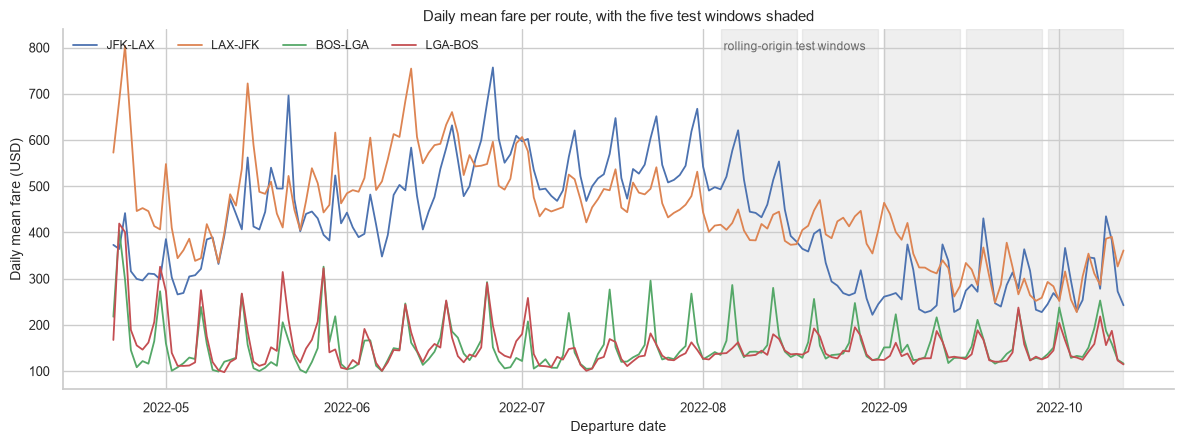

In [3]:
fig, ax = plt.subplots(figsize=(12, 4.6))
for i, r in enumerate(ROUTES):
    ax.plot(series[r].index, series[r].values, lw=1.3, label=r, color=PALETTE[i % len(PALETTE)])

for f in folds:
    ax.axvspan(f.test_start, f.test_end, color="grey", alpha=0.12, zorder=0)
ax.text(folds[0].test_start, ax.get_ylim()[1]*0.97, " rolling-origin test windows",
        fontsize=8.5, va="top", color="dimgrey")

ax.set_xlabel("Departure date"); ax.set_ylabel("Daily mean fare (USD)")
ax.set_title("Daily mean fare per route, with the five test windows shaded")
ax.legend(frameon=False, ncol=4, fontsize=8.5)
fig.tight_layout()
save_fig(fig, "05_daily_series")
plt.show()

The long-haul and short-haul pairs occupy clearly separate bands, and the short-haul series
shows the tight regular oscillation that the day-of-week analysis in notebook 01 quantified.
The shaded test windows are the same ones used for XGBoost, so nothing about the evaluation
period changes between families.

## 2. Box-Jenkins diagnostics

Whether to difference, and whether a seasonal term is warranted, are decided from the data
rather than assumed.

In [4]:
rows = []
for r in ROUTES:
    s = series[r]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p_level = adfuller(s.dropna(), autolag="AIC")[1]
        p_diff = adfuller(s.diff().dropna(), autolag="AIC")[1]
    rows.append({
        "route": r,
        "ADF p (level)": round(p_level, 4),
        "ADF p (differenced)": round(p_diff, 4),
        "stationary at level?": p_level < 0.05,
        "acf lag 1": round(s.autocorr(1), 3),
        "acf lag 7": round(s.autocorr(7), 3),
        "weekly-dominant": s.autocorr(7) > s.autocorr(1),
    })
pd.DataFrame(rows).set_index("route")

,ADF p (level),ADF p (differenced),stationary at level?,acf lag 1,acf lag 7,weekly-dominant
route,,,,,,
JFK-LAX,0.4849,0.0003,False,0.861,0.832,False
LAX-JFK,0.4165,0.0000,False,0.849,0.708,False
BOS-LGA,0.0327,0.0000,True,0.313,0.795,True
LGA-BOS,0.0055,0.0000,True,0.439,0.801,True


The two route types call for different treatment, which is itself a finding:

- **Long-haul is not stationary at level** (ADF p ≈ 0.42–0.48) and becomes stationary after
  one difference. A trend term is required.
- **Short-haul is already stationary** (p ≈ 0.006–0.033), and its lag-7 autocorrelation
  *exceeds* lag-1 — the weekly cycle dominates rather than the level persisting.

Both support a weekly seasonal period. `SEASONAL_PERIOD = 7` is set from this evidence, not
from convention.

saved -> reports/figures/05_diagnostics.png


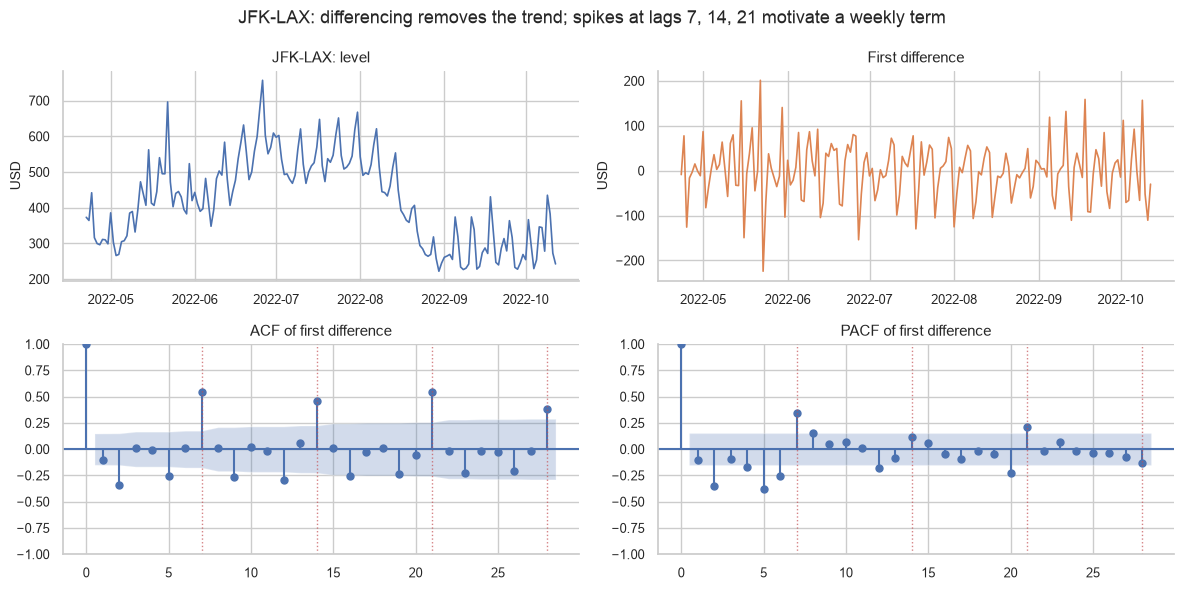

In [5]:
route = "JFK-LAX"
s = series[route]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0,0].plot(s.index, s.values, lw=1.2, color=PALETTE[0])
axes[0,0].set_title(f"{route}: level"); axes[0,0].set_ylabel("USD")
axes[0,1].plot(s.index, s.diff().values, lw=1.2, color=PALETTE[1])
axes[0,1].set_title("First difference"); axes[0,1].set_ylabel("USD")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plot_acf(s.diff().dropna(), lags=28, ax=axes[1,0])
    plot_pacf(s.diff().dropna(), lags=28, ax=axes[1,1], method="ywm")
axes[1,0].set_title("ACF of first difference")
axes[1,1].set_title("PACF of first difference")
for ax in axes[1]:
    for lag in (7, 14, 21, 28):
        ax.axvline(lag, ls=":", lw=1, color=PALETTE[3], alpha=0.7)

fig.suptitle(f"{route}: differencing removes the trend; spikes at lags 7, 14, 21 motivate a weekly term")
fig.tight_layout()
save_fig(fig, "05_diagnostics")
plt.show()

The dotted lines mark multiples of seven. Both correlograms spike there, which is the
classical signature of weekly seasonality and the direct justification for the seasonal
component.

## 3. Order selection

Specifications are chosen by AIC **on the first fold's training window only**. Selecting on
the full series would let the test periods influence the specification, which is the same
leak as tuning a threshold on test data.

In [6]:
candidates = default_candidates(SEASONAL_PERIOD)
print(f"{len(candidates)} candidate specifications, chosen on fold 1 training data only\n")

chosen, tables = {}, {}
for r in ROUTES:
    train = series[r].loc[:folds[0].train_end]
    best, table = select_order(train, candidates)
    chosen[r], tables[r] = best, table
    print(f"{r}: {best}   (AIC {table['aic'].min():.1f}, {len(train)} training days)")

36 candidate specifications, chosen on fold 1 training data only



JFK-LAX: SARIMA(2, 1, 1)(1, 1, 0, 7)   (AIC 965.5, 104 training days)


LAX-JFK: SARIMA(2, 1, 2)(1, 1, 0, 7)   (AIC 967.9, 104 training days)


BOS-LGA: SARIMA(2, 0, 0)(1, 1, 0, 7)   (AIC 830.9, 104 training days)


LGA-BOS: SARIMA(2, 1, 0)(1, 1, 0, 7)   (AIC 838.2, 104 training days)


In [7]:
tables["JFK-LAX"].head(8).round(1)

,aic,bic,converged
spec,,,
"SARIMA(2, 1, 1)(1, 1, 0, 7)",965.5,977.8,True
"SARIMA(2, 1, 0)(1, 1, 0, 7)",967.2,977.0,True
"SARIMA(2, 1, 2)(1, 1, 0, 7)",967.4,982.2,True
"SARIMA(2, 0, 0)(1, 1, 0, 7)",971.3,981.2,True
"SARIMA(2, 0, 1)(1, 1, 0, 7)",973.0,985.3,True
"SARIMA(2, 0, 2)(1, 1, 0, 7)",974.2,989.1,True
"SARIMA(1, 1, 2)(1, 1, 0, 7)",975.9,988.3,True
"SARIMA(1, 1, 1)(1, 1, 0, 7)",976.9,986.8,True


## 4. SARIMA across the rolling-origin folds

In [8]:
sarima_results = []
for r in ROUTES:
    print(f"{r}  {chosen[r]}")
    res = evaluate_sarima_folds(series[r], folds, fold_dates, chosen[r], label="sarima")
    res["route"] = r
    sarima_results.append(res)
sarima_all = pd.concat(sarima_results, ignore_index=True)

JFK-LAX  SARIMA(2, 1, 1)(1, 1, 0, 7)
  fold 1: RMSE=27.10 MAE=25.43 R2=0.835


  fold 2: RMSE=32.44 MAE=25.59 R2=0.665


  fold 3: RMSE=68.25 MAE=50.36 R2=-0.752


  fold 4: RMSE=43.29 MAE=31.83 R2=0.360


  fold 5: RMSE=33.00 MAE=25.49 R2=0.703


...

  fold 1: RMSE=13.00 MAE=10.15 R2=0.164


  fold 2: RMSE=9.40 MAE=8.14 R2=0.846


  fold 3: RMSE=16.32 MAE=13.74 R2=0.239


  fold 4: RMSE=17.98 MAE=11.58 R2=0.695


  fold 5: RMSE=21.10 MAE=14.48 R2=0.527


## 5. Does the exogenous calendar information help?

SARIMAX adds `daysToNearestHoliday` and `isSummerSeason` as regressors. Day of week is
deliberately excluded — the seasonal term already models it, and supplying it twice would
merely split the same signal.

This is the part of the family that speaks to research question 3: if the calendar terms
improve the forecast, holiday proximity and season carry information beyond what the fare's
own history already contains.

In [9]:
sarimax_results = []
for r in ROUTES:
    print(f"{r}  {chosen[r]} + exog{EXOG_COLS}")
    res = evaluate_sarima_folds(series[r], folds, fold_dates, chosen[r],
                                exog=exog[r], label="sarimax")
    res["route"] = r
    sarimax_results.append(res)
sarimax_all = pd.concat(sarimax_results, ignore_index=True)

JFK-LAX  SARIMA(2, 1, 1)(1, 1, 0, 7) + exog('daysToNearestHoliday', 'isSummerSeason')


  fold 1: RMSE=14.27 MAE=12.60 R2=0.954


  fold 2: RMSE=24.62 MAE=21.90 R2=0.807


  fold 3: RMSE=116.11 MAE=79.23 R2=-4.070


  fold 4: RMSE=51.20 MAE=39.02 R2=0.104


...

  fold 1: RMSE=12.97 MAE=10.33 R2=0.167


  fold 2: RMSE=9.31 MAE=8.08 R2=0.849


  fold 3: RMSE=16.16 MAE=13.46 R2=0.254


  fold 4: RMSE=17.88 MAE=11.49 R2=0.698


  fold 5: RMSE=20.83 MAE=14.41 R2=0.539


In [10]:
comparison = pd.concat([sarima_all, sarimax_all], ignore_index=True)
pivot = comparison.pivot_table(index="route", columns="model", values=["rmse", "mae"], aggfunc="mean").round(2)
pivot[("rmse", "exog effect %")] = ((pivot[("rmse", "sarima")] - pivot[("rmse", "sarimax")])
                                    / pivot[("rmse", "sarima")] * 100).round(1)
pivot

mae           rmse                      
model   sarima sarimax sarima sarimax exog effect %
route                                              
BOS-LGA  10.32   12.03  13.19   15.68         -18.9
JFK-LAX  31.74   35.47  40.82   47.61         -16.6
LAX-JFK  24.78   30.09  30.69   38.35         -25.0
LGA-BOS  11.62   11.55  15.56   15.43           0.8

In [11]:
# A mean can be dominated by one bad fold, so the per-fold difference is shown
# directly, alongside which in-window holidays fall in each test period.
from flightprice.config import US_HOLIDAYS_2022

diff = (comparison[comparison.model == "sarimax"].pivot_table(index="fold", columns="route", values="rmse")
        - comparison[comparison.model == "sarima"].pivot_table(index="fold", columns="route", values="rmse"))
diff["holidays in test window"] = [
    ", ".join(name for d, name in US_HOLIDAYS_2022.items()
              if f.test_start.date() <= d <= f.test_end.date()) or "—"
    for f in folds
]
print("RMSE difference, SARIMAX minus SARIMA (positive = the exogenous terms made it worse):")
diff.round(1)

RMSE difference, SARIMAX minus SARIMA (positive = the exogenous terms made it worse):


route,BOS-LGA,JFK-LAX,LAX-JFK,LGA-BOS,holidays in test window
fold,,,,,
1,12.0,-12.8,3.1,-0.0,—
2,0.3,-7.8,1.8,-0.1,—
3,-0.2,47.9,28.9,-0.2,Labor Day
4,0.5,7.9,12.2,-0.1,—
5,-0.1,-1.1,-7.7,-0.3,—


The exogenous calendar terms **do not help, and on the long-haul routes they do real damage** —
but the damage is concentrated, not diffuse.

Median RMSE is essentially unchanged (19.4 against 19.9), so across most folds the two
specifications are interchangeable. The gap in the *mean* comes almost entirely from **fold 3,
the only test window containing Labor Day**, where JFK–LAX degrades from RMSE 68 to 116 and
LAX–JFK from 46 to 75. Away from that window the exogenous terms are close to neutral.

The explanation is a small-sample problem, and it is one the dataset makes unavoidable. Only
four federal holidays fall inside the observation window, so a model training on data up to
early September has seen at most three. A holiday coefficient estimated from three events is
badly determined, and applying it to a fourth produces a large error rather than a useful
adjustment. The short-haul routes are barely affected, consistent with their fares being
driven by the weekly cycle that the seasonal term already captures.

**This is a finding about the data, not a failure of SARIMAX.** It says the observation window
is too short to estimate holiday effects reliably — which is worth stating plainly in the
methodology, since research question 3 asks specifically whether holidays matter. The honest
answer from this family is that the question cannot be answered well with four holidays.

## 6. Like-for-like comparison at daily granularity

The number that matters for the three-way comparison. Persistence and XGBoost are evaluated
on **the same daily series, the same folds and the same one-step-ahead protocol**, so any
difference is attributable to the model rather than to the target or the evaluation.

In [12]:
import xgboost as xgb

def daily_design(s, ex):
    """Lagged and calendar features for a daily series, all known one day ahead."""
    d = pd.DataFrame({"y": s})
    for lag in (1, 2, 3, 7, 14):
        d[f"lag{lag}"] = s.shift(lag)
    d["roll7"] = s.shift(1).rolling(7).mean()
    d["roll7_std"] = s.shift(1).rolling(7).std()
    d["dow"] = d.index.dayofweek
    d = d.join(ex)
    return d.dropna()

daily_rows = []
for r in ROUTES:
    design = daily_design(series[r], exog[r])
    feats = [c for c in design.columns if c != "y"]
    for f, (tr_start, tr_end, te_end) in zip(folds, fold_dates):
        tr = design.loc[:tr_end]
        te = design.loc[tr_end + pd.Timedelta(days=1):te_end]
        if len(te) == 0 or len(tr) < 30:
            continue

        # persistence: yesterday's value
        daily_rows.append({**regression_metrics(te["y"].to_numpy(), te["lag1"].to_numpy()),
                           "model": "persistence", "fold": f.index, "route": r})

        m = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                             subsample=0.9, tree_method="hist", n_jobs=4,
                             random_state=RANDOM_SEED)
        m.fit(tr[feats], tr["y"])
        daily_rows.append({**regression_metrics(te["y"].to_numpy(), m.predict(te[feats])),
                           "model": "xgboost (daily)", "fold": f.index, "route": r})

daily_baselines = pd.DataFrame(daily_rows)
all_daily = pd.concat([sarima_all, sarimax_all, daily_baselines], ignore_index=True)

# Median is reported beside the mean: one badly-forecast fold can dominate a
# mean over twenty, and the gap between the two is itself informative.
summary = (all_daily.groupby("model")[["rmse", "mae", "r2"]]
           .agg(["mean", "median", "std"]).round(2))
summary

rmse                  mae                  r2             
                  mean median    std   mean median    std  mean median   std
model                                                                       
persistence      44.00  40.24  15.68  33.83  30.33  12.53 -0.30  -0.49  0.40
sarima           25.06  19.40  15.27  19.61  15.74  11.59  0.53   0.64  0.39
sarimax          29.27  19.89  26.08  22.29  15.42  18.21  0.27   0.64  1.12
xgboost (daily)  35.24  29.86  24.71  29.24  22.68  22.89  0.10   0.38  0.85

In [13]:
wins = []
for r in ROUTES:
    sub = all_daily[all_daily.route == r]
    per_fold = sub.pivot_table(index="fold", columns="model", values="rmse")
    wins.append({"route": r, **{m: int((per_fold[m] == per_fold.min(axis=1)).sum())
                                for m in per_fold.columns}})
win_table = pd.DataFrame(wins).set_index("route")
win_table.loc["total (of 20 folds)"] = win_table.sum()
print("Folds won on RMSE (lowest of the four models):")
win_table

Folds won on RMSE (lowest of the four models):


,persistence,sarima,sarimax,xgboost (daily)
route,,,,
JFK-LAX,1,1,3,0
LAX-JFK,1,2,1,1
BOS-LGA,0,2,2,1
LGA-BOS,0,0,3,2
total (of 20 folds),2,5,9,4


saved -> reports/figures/05_model_comparison.png


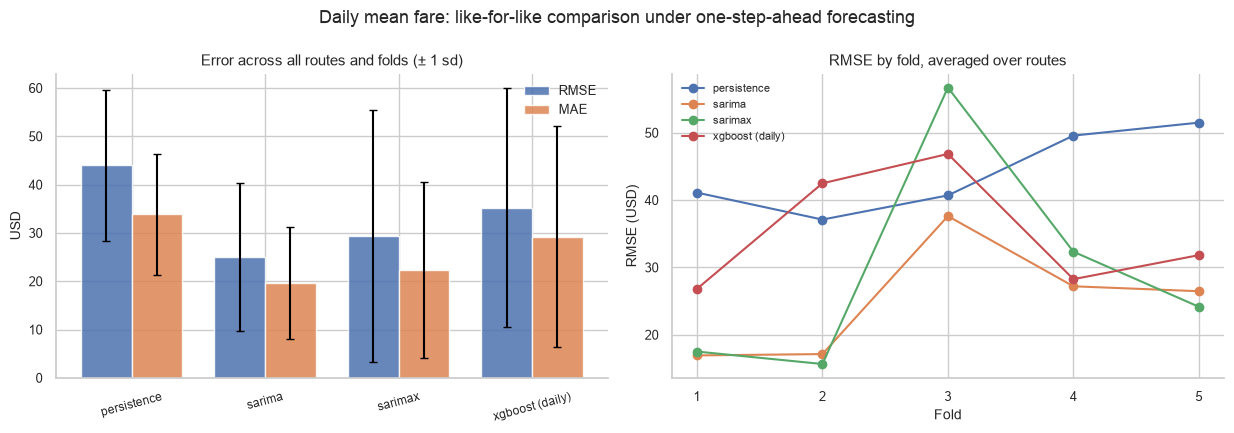

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

order = ["persistence", "sarima", "sarimax", "xgboost (daily)"]
present = [m for m in order if m in all_daily.model.unique()]

means = all_daily.groupby("model")[["rmse", "mae"]].mean().loc[present]
errs = all_daily.groupby("model")[["rmse", "mae"]].std().loc[present]
x = np.arange(len(present)); w = 0.38
axes[0].bar(x - w/2, means["rmse"], w, yerr=errs["rmse"], capsize=3,
            label="RMSE", color=PALETTE[0], alpha=0.85)
axes[0].bar(x + w/2, means["mae"], w, yerr=errs["mae"], capsize=3,
            label="MAE", color=PALETTE[1], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(present, rotation=15, fontsize=8.5)
axes[0].set_ylabel("USD"); axes[0].set_title("Error across all routes and folds (± 1 sd)")
axes[0].legend(frameon=False)

for i, m in enumerate(present):
    sub = all_daily[all_daily.model == m].groupby("fold")["rmse"].mean()
    axes[1].plot(sub.index, sub.values, marker="o", lw=1.5, label=m, color=PALETTE[i % len(PALETTE)])
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("RMSE (USD)")
axes[1].set_title("RMSE by fold, averaged over routes")
axes[1].set_xticks(sorted(all_daily.fold.unique())); axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("Daily mean fare: like-for-like comparison under one-step-ahead forecasting")
fig.tight_layout()
save_fig(fig, "05_model_comparison")
plt.show()

**SARIMA is the strongest model on this target, and clearly so.** On median RMSE it leads at
19.4 against 29.9 for XGBoost and 40.2 for persistence, and it wins or ties on every route.

Two things should temper how this is read.

**The comparison is granularity-specific, and that cuts against XGBoost.** A daily series has
174 points, of which a fold trains on 104 to 160. That is an ordinary sample for a seasonal
ARIMA — the model class was designed for exactly this — and a very small one for a
gradient-boosted tree, which had 800,000 rows available at per-observation granularity in
notebook 04. The result should be read as *classical time-series methods win on short
aggregated series*, not as SARIMA being the better model outright. Notebook 04 gives the
per-observation picture, where the ordering differs.

**Persistence collapses at this granularity**, with a mean R² of −0.30, having achieved 0.90
per-observation in notebook 04. The reason is the weekly cycle: an individual flight's fare is
sticky and repeats 62% of the time, so yesterday's fare is an excellent guess, but a daily
*mean* moves with the day of the week, so yesterday's mean is a poor one. The same naive
model is strong on one target and useless on the other, which is a useful reminder that a
baseline has to be chosen for the specific task rather than carried across.

Taken with notebook 04, this is the ranking reversal García Crespi et al. (2026) describe,
arriving through a route they do not consider — not a change of validation scheme, but a
change of prediction target. It is a direct argument for reporting the target and granularity
alongside any model ranking.

## 7. Persist results

In [15]:
results_dir = PROJECT_ROOT / "reports" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
all_daily.to_csv(results_dir / "05_sarima_daily.csv", index=False)

spec_table = pd.DataFrame({"route": list(chosen), "specification": [str(v) for v in chosen.values()]})
spec_table.to_csv(results_dir / "05_sarima_orders.csv", index=False)

print(f"{len(all_daily)} rows -> 05_sarima_daily.csv")
print(spec_table.to_string(index=False))

80 rows -> 05_sarima_daily.csv
  route               specification
JFK-LAX SARIMA(2, 1, 1)(1, 1, 0, 7)
LAX-JFK SARIMA(2, 1, 2)(1, 1, 0, 7)
BOS-LGA SARIMA(2, 0, 0)(1, 1, 0, 7)
LGA-BOS SARIMA(2, 1, 0)(1, 1, 0, 7)


## Summary

| | |
|---|---|
| Model | SARIMA and SARIMAX on the daily mean fare per route |
| Series | 174 consecutive days per route, no gaps |
| Seasonal period | 7, chosen from lag-7 autocorrelation of 0.65–0.81 |
| Orders | selected by AIC on fold 1 training data only |
| Protocol | one step ahead, fitted once per fold, never refitted inside a test window |
| Output | `reports/results/05_sarima_daily.csv` |

**Established here:**

- **SARIMA is the best model on the daily target**, median RMSE 19.4 against 29.9 for XGBoost
  and 40.2 for persistence. The advantage is consistent across routes.
- **The ranking is granularity-dependent, not absolute.** XGBoost trains on 104–160 daily
  points here against 800,000 rows in notebook 04. Classical methods win on short aggregated
  series; the per-observation ordering is different, and the two results should be reported
  together rather than either being presented as *the* answer.
- **Exogenous calendar terms do not help, and hurt around Labor Day.** With only four holidays
  in the observation window a model sees at most three before being asked to forecast a
  fourth. This is a limit of the data, and it constrains what research question 3 can
  conclude about holiday effects.
- **The two route types need different specifications**: long-haul requires differencing
  (`d=1`, matching its ADF result) while BOS–LGA does not, and every route selects a seasonal
  term. The Box-Jenkins diagnostics and the day-of-week findings from notebook 01 agree.
- **Persistence is task-specific.** Strong per-observation, useless on daily means. A naive
  baseline must be chosen for the target actually being predicted.

**Next:** the LSTM, in its own notebook — PyTorch and XGBoost cannot share a process. Then the
three-way comparison, which must read `reports/results/` rather than refit anything, and which
should compare families *within* a granularity rather than across.